# Entrenamiento de Modelo BiLSTM para Deteccion de Arritmias Cardiacas

Este notebook implementa un modelo BiLSTM para clasificacion binaria de ritmo cardiaco.
Enfocado en diagnostico preventivo low-cost.

**Dataset:** MIT-BIH Arrhythmia Database  
**Clases:** 2 categorias (Normal / Anormal)  
**Modelo:** BiLSTM de 2 capas con 128/64 unidades ocultas

---

## 1. Instalacion de Dependencias

Instalamos las librerias necesarias para el procesamiento de senales ECG y entrenamiento del modelo.

In [6]:
# Suprimir warnings
import warnings
warnings.filterwarnings('ignore')

# Instalar dependencias principales
!pip install wfdb numpy torch matplotlib scikit-learn

## 2. Importacion de Librerias

Importamos todas las librerias necesarias y configuramos el dispositivo de computo (GPU/CPU).

In [7]:
# Procesamiento de senales y datos
import wfdb
import numpy as np
import pandas as pd
from collections import Counter
import pickle
import os
from datetime import datetime

# Machine Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    recall_score, 
    f1_score,
    precision_score
)
from sklearn.utils.class_weight import compute_class_weight

# Visualizacion
import matplotlib.pyplot as plt

# Configurar dispositivo (GPU si esta disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU: Tesla T4


## 3. Configuracion de Hiperparametros

Definimos todos los parametros del modelo y del entrenamiento en un solo lugar para facilitar experimentos.

In [8]:
# ==================== PARAMETROS DEL MODELO ====================
INPUT_SIZE = 1              # 1 caracteristica (senal ECG)
HIDDEN_SIZE_1 = 128         # Primera capa BiLSTM
HIDDEN_SIZE_2 = 64          # Segunda capa BiLSTM
NUM_LAYERS = 2              # Numero de capas LSTM
NUM_CLASSES = 2             # 2 clases: Normal / Anormal

# ==================== PARAMETROS DE ENTRENAMIENTO ====================
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 15
REDUCE_LR_PATIENCE = 5

# ==================== PARAMETROS DE SENAL ====================
WINDOW_SIZE = 180           # Tamano de ventana en muestras
SAMPLING_RATE = 360         # Frecuencia de muestreo (Hz)
WINDOW_DURATION = WINDOW_SIZE / SAMPLING_RATE  # 0.5 segundos

# ==================== RUTAS ====================
DATASET_PATH = './mitdb'
MODEL_PATH = 'best_ecg_bilstm_model.pth'
SCALER_PATH = 'scaler.pkl'
ENCODER_PATH = 'label_encoder.pkl'

print("Configuracion cargada")
print(f"Ventana: {WINDOW_SIZE} muestras ({WINDOW_DURATION} segundos)")
print(f"Clases: {NUM_CLASSES} (Normal / Anormal)")
print(f"Epocas: {NUM_EPOCHS}")

Configuracion cargada
Ventana: 180 muestras (0.5 segundos)
Clases: 2 (Normal / Anormal)
Epocas: 50


## 4. Mapeo de Clases Binario

Clasificacion binaria para diagnostico preventivo:

- **Normal**: N, L, R (ritmo sinusal normal y bloqueos de rama)
- **Anormal**: Todos los demas (SVEB, VEB, Fusion, Paced, Unknown)

Este enfoque simplificado es ideal para:
- Dispositivos de bajo costo
- Screening preventivo
- Deteccion temprana de anomalias

In [9]:
# ==================== MAPEO MIT-BIH -> BINARIO ====================
MITBIH_TO_BINARY = {
    # Normal beats (ritmo sinusal normal y variantes)
    'N': 'Normal',    # Normal beat
    'L': 'Normal',    # Left bundle branch block
    'R': 'Normal',    # Right bundle branch block
    
    # Anormal beats (cualquier arritmia o anomalia)
    'A': 'Anormal',   # Atrial premature beat
    'J': 'Anormal',   # Nodal (junctional) premature beat
    'S': 'Anormal',   # Supraventricular premature beat
    'V': 'Anormal',   # Premature ventricular contraction
    'E': 'Anormal',   # Ventricular escape beat
    '!': 'Anormal',   # Ventricular flutter
    'F': 'Anormal',   # Fusion of ventricular and normal beat
    '/': 'Anormal',   # Paced beat
    'f': 'Anormal',   # Fusion of paced and normal beat
    'Q': 'Anormal',   # Unclassifiable beat
    'u': 'Anormal',   # Unknown
}

# ==================== MAPEO CLASES -> INDICES ====================
CLASS_MAPPING = {
    'Normal': 0,
    'Anormal': 1
}

REVERSE_CLASS_MAPPING = {v: k for k, v in CLASS_MAPPING.items()}

CLASS_NAMES = {
    0: 'Normal',
    1: 'Anormal'
}

print("Mapeo de clases configurado")
print(f"Clases: {list(CLASS_MAPPING.keys())}")

Mapeo de clases configurado
Clases: ['Normal', 'Anormal']


## 5. Descarga del Dataset MIT-BIH

Descargamos automaticamente el dataset MIT-BIH Arrhythmia Database (48 registros).

In [10]:
print("Descargando MIT-BIH Arrhythmia Database...")

# Descargar todos los registros
wfdb.dl_database('mitdb', DATASET_PATH)

# Verificar descarga
files = os.listdir(DATASET_PATH)
records = sorted(set([f.split('.')[0] for f in files if '.' in f]))

print(f"Descarga completada")
print(f"Registros descargados: {len(records)}")
print(f"Ubicacion: {DATASET_PATH}")

Descargando MIT-BIH Arrhythmia Database...
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 2

## 6. Funciones de Carga y Procesamiento

Definimos las funciones para cargar los registros ECG y segmentar las senales en ventanas.

In [11]:
def load_record(record_number, dataset_path=DATASET_PATH):
    """
    Carga un registro MIT-BIH con su senal ECG y anotaciones.
    
    Args:
        record_number (str): Numero de registro (ej: '100', '101')
        dataset_path (str): Ruta al directorio del dataset
        
    Returns:
        tuple: (signal, symbols, samples, fs) o (None, None, None, None) si hay error
    """
    try:
        # Cargar registro y anotaciones
        record = wfdb.rdrecord(f'{dataset_path}/{record_number}')
        annotation = wfdb.rdann(f'{dataset_path}/{record_number}', 'atr')
        
        # Extraer senal de Lead II (primera derivacion)
        signal = record.p_signal[:, 0] if record.p_signal.ndim > 1 else record.p_signal
        
        # Resamplear a 360 Hz si es necesario
        if record.fs != SAMPLING_RATE:
            original_length = len(signal)
            target_length = int(original_length * SAMPLING_RATE / record.fs)
            indices = np.linspace(0, original_length - 1, target_length)
            signal = np.interp(indices, np.arange(original_length), signal)
        
        return signal, annotation.symbol, annotation.sample, record.fs
        
    except Exception as e:
        print(f"Error en registro {record_number}: {e}")
        return None, None, None, None


def segment_signal(signal, symbols, samples, window_size=WINDOW_SIZE):
    """
    Segmenta una senal ECG en ventanas centradas en cada latido.
    
    Args:
        signal (np.array): Senal ECG completa
        symbols (list): Lista de simbolos de anotacion para cada latido
        samples (list): Lista de indices de muestra para cada latido
        window_size (int): Tamano de cada ventana en muestras
        
    Returns:
        tuple: (segments, labels) - listas de segmentos y sus etiquetas
    """
    segments = []
    labels = []
    
    for i in range(len(symbols) - 1):
        # Posicion del latido actual
        beat_pos = samples[i]
        
        # Calcular inicio y fin de la ventana (centrada en el latido)
        start = beat_pos - window_size // 2
        end = beat_pos + window_size // 2
        
        # Verificar que la ventana esta dentro de los limites
        if start < 0 or end >= len(signal):
            continue
        
        # Extraer segmento
        segment = signal[start:end]
        
        # Verificar longitud exacta
        if len(segment) != window_size:
            continue
        
        # Mapear simbolo MIT-BIH a clase binaria
        symbol = symbols[i]
        binary_class = MITBIH_TO_BINARY.get(symbol, 'Anormal')
        
        # Guardar solo clases validas
        if binary_class in CLASS_MAPPING:
            segments.append(segment)
            labels.append(binary_class)
    
    return segments, labels


print("Funciones de procesamiento definidas")

Funciones de procesamiento definidas


## 7. Carga y Procesamiento de Datos

Procesamos todos los registros del dataset y extraemos segmentos de ECG con sus etiquetas.

In [12]:
print("Procesando registros MIT-BIH...\n")

all_segments = []
all_labels = []

# Obtener lista de registros
files = os.listdir(DATASET_PATH)
records = sorted(set([f.split('.')[0] for f in files if '.' in f]))

# Procesar todos los registros
# Para prueba rapida, cambiar [:] por [:10]
for record_num in records[:]:
    signal, symbols, samples, fs = load_record(record_num)
    
    if signal is not None:
        segments, labels = segment_signal(signal, symbols, samples)
        all_segments.extend(segments)
        all_labels.extend(labels)
        print(f"Registro {record_num}: {len(segments):,} segmentos")

# Mostrar estadisticas
print(f"\nProcesamiento completado")
print(f"Total de segmentos: {len(all_segments):,}")

# Distribucion de clases original (desbalanceada)
label_counts = Counter(all_labels)
print(f"\nDistribucion de clases original:")
for label, count in sorted(label_counts.items()):
    percentage = count / len(all_labels) * 100
    print(f"  {label:10s}: {count:6,} ({percentage:5.1f}%)")

Procesando registros MIT-BIH...

Registro 100: 2,271 segmentos
Registro 101: 1,871 segmentos
Registro 102: 2,190 segmentos
Registro 103: 2,089 segmentos
Registro 104: 2,308 segmentos
Registro 105: 2,689 segmentos
Registro 106: 2,096 segmentos
Registro 107: 2,138 segmentos
Registro 108: 1,821 segmentos
Registro 109: 2,533 segmentos
Registro 111: 2,131 segmentos
Registro 112: 2,548 segmentos
Registro 113: 1,794 segmentos
Registro 114: 1,888 segmentos
Registro 115: 1,960 segmentos
Registro 116: 2,420 segmentos
Registro 117: 1,537 segmentos
Registro 118: 2,298 segmentos
Registro 119: 2,092 segmentos
Registro 121: 1,874 segmentos
Registro 122: 2,477 segmentos
Registro 123: 1,516 segmentos
Registro 124: 1,633 segmentos
Registro 200: 2,790 segmentos
Registro 201: 2,037 segmentos
Registro 202: 2,145 segmentos
Registro 203: 3,105 segmentos
Registro 205: 2,670 segmentos
Registro 207: 2,382 segmentos
Registro 208: 3,037 segmentos
Registro 209: 3,050 segmentos
Registro 210: 2,682 segmentos
Registr

## 8. Preprocesamiento con Class Weights

Aplicamos normalizacion y calculamos class weights para manejar el desbalance de clases.
No usamos SMOTE para evitar crear datos sinteticos que no existen fisiologicamente.

In [13]:
print("Preprocesando datos...\n")

# Convertir a arrays numpy
X = np.array(all_segments)
y = np.array(all_labels)

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

# Codificar etiquetas a numeros
label_encoder = LabelEncoder()
label_encoder.fit(['Normal', 'Anormal'])
y_encoded = label_encoder.transform(y)

# Normalizar senales con StandardScaler
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)
print("Normalizacion aplicada")

# Calcular class weights para manejar desbalance
print("\nCalculando class weights...")
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Class weights calculados:")
for class_idx, weight in enumerate(class_weights):
    class_name = REVERSE_CLASS_MAPPING[class_idx]
    print(f"  {class_name:10s}: {weight:.4f}")

# Dividir en entrenamiento y validacion (80/20)
print("\nDividiendo en train/val...")
X_train, X_val, y_train, y_val = train_test_split(
    X_normalized, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

# Convertir a tensores PyTorch
X_train = torch.FloatTensor(X_train).unsqueeze(-1)  # (N, 180, 1)
X_val = torch.FloatTensor(X_val).unsqueeze(-1)
y_train = torch.LongTensor(y_train)
y_val = torch.LongTensor(y_val)

print(f"Division completada")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")

# Mostrar distribucion en train
train_counts = Counter(y_train.numpy())
print(f"\nDistribucion en Train:")
for class_idx, count in sorted(train_counts.items()):
    class_name = REVERSE_CLASS_MAPPING[class_idx]
    percentage = count / len(y_train) * 100
    print(f"  {class_name:10s}: {count:6,} ({percentage:5.1f}%)")

Preprocesando datos...

Forma de X: (112543, 180)
Forma de y: (112543,)
Normalizacion aplicada

Calculando class weights...
Class weights calculados:
  Normal    : 2.5336
  Anormal   : 0.6229

Dividiendo en train/val...
Division completada
  Train: torch.Size([90034, 180, 1])
  Val:   torch.Size([22509, 180, 1])

Distribucion en Train:
  Normal    : 17,768 ( 19.7%)
  Anormal   : 72,266 ( 80.3%)


## 9. Dataset y DataLoader de PyTorch

Creamos clases personalizadas para manejar los datos en PyTorch.

In [14]:
class ECGDataset(Dataset):
    """
    Dataset personalizado para senales ECG.
    
    Args:
        features (torch.Tensor): Senales ECG de forma (N, seq_len, 1)
        labels (torch.Tensor): Etiquetas de clase (N,)
    """
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


# Crear datasets
train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)

# Crear dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

print("Dataset y DataLoaders creados")
print(f"  Batches de entrenamiento: {len(train_loader)}")
print(f"  Batches de validacion: {len(val_loader)}")

Dataset y DataLoaders creados
  Batches de entrenamiento: 2814
  Batches de validacion: 704


## 10. Definicion del Modelo BiLSTM

Implementamos un modelo BiLSTM de 2 capas con Dropout para clasificacion binaria.

In [15]:
class BiLSTMModel(nn.Module):
    """
    Modelo BiLSTM de 2 capas para clasificacion binaria de arritmias cardiacas.
    
    Arquitectura:
        - BiLSTM Layer 1: 128 unidades ocultas
        - BiLSTM Layer 2: 64 unidades ocultas
        - Dropout: 0.3
        - Fully Connected: 2 clases de salida (Normal / Anormal)
    
    Args:
        input_size (int): Tamano de entrada (1 para ECG univariado)
        hidden_size_1 (int): Unidades ocultas capa 1
        hidden_size_2 (int): Unidades ocultas capa 2
        num_classes (int): Numero de clases de salida (2)
        dropout (float): Tasa de dropout
    """
    def __init__(self, input_size=1, hidden_size_1=128, hidden_size_2=64, 
                 num_classes=2, dropout=0.3):
        super(BiLSTMModel, self).__init__()
        
        # Primera capa BiLSTM
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size_1,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        # Segunda capa BiLSTM
        self.lstm2 = nn.LSTM(
            input_size=hidden_size_1 * 2,  # x2 por bidireccional
            hidden_size=hidden_size_2,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        # Dropout para regularizacion
        self.dropout = nn.Dropout(dropout)
        
        # Capa completamente conectada
        self.fc = nn.Linear(hidden_size_2 * 2, num_classes)
    
    def forward(self, x):
        """
        Forward pass del modelo.
        
        Args:
            x (torch.Tensor): Input de forma (batch_size, seq_len, input_size)
            
        Returns:
            torch.Tensor: Logits de forma (batch_size, num_classes)
        """
        # Primera capa BiLSTM
        lstm1_out, _ = self.lstm1(x)
        lstm1_out = self.dropout(lstm1_out)
        
        # Segunda capa BiLSTM
        lstm2_out, _ = self.lstm2(lstm1_out)
        lstm2_out = self.dropout(lstm2_out)
        
        # Tomar ultima salida temporal
        last_output = lstm2_out[:, -1, :]
        
        # Clasificacion
        logits = self.fc(last_output)
        
        return logits


# Crear modelo
model = BiLSTMModel(
    input_size=INPUT_SIZE,
    hidden_size_1=HIDDEN_SIZE_1,
    hidden_size_2=HIDDEN_SIZE_2,
    num_classes=NUM_CLASSES
).to(device)

# Mostrar arquitectura
print("Modelo BiLSTM creado\n")
print(model)
print(f"\nParametros totales: {sum(p.numel() for p in model.parameters()):,}")

Modelo BiLSTM creado

BiLSTMModel(
  (lstm1): LSTM(1, 128, batch_first=True, bidirectional=True)
  (lstm2): LSTM(256, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

Parametros totales: 299,266


## 11. Configuracion de Entrenamiento

Configuramos el optimizador, funcion de perdida con class weights y schedulers.

In [17]:
# Funcion de perdida con class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizador Adam
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (reduce LR cuando el loss se estanca)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=REDUCE_LR_PATIENCE,
)

print("Configuracion de entrenamiento lista")
print(f"  Optimizador: Adam (lr={LEARNING_RATE})")
print(f"  Loss: CrossEntropyLoss con class weights")
print(f"  Scheduler: ReduceLROnPlateau (patience={REDUCE_LR_PATIENCE})")

Configuracion de entrenamiento lista
  Optimizador: Adam (lr=0.001)
  Loss: CrossEntropyLoss con class weights
  Scheduler: ReduceLROnPlateau (patience=5)


## 12. Loop de Entrenamiento

Entrenamos el modelo con early stopping y guardamos el mejor modelo.

In [18]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Entrena el modelo por una epoca.
    
    Returns:
        float: Loss promedio de la epoca
    """
    model.train()
    total_loss = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def validate_epoch(model, val_loader, criterion, device):
    """
    Evalua el modelo en el conjunto de validacion.
    
    Returns:
        tuple: (loss, accuracy, recall, f1_score, precision)
    """
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            
            preds = output.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    # Calcular metricas
    avg_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds, average='binary')
    f1 = f1_score(all_targets, all_preds, average='binary')
    precision = precision_score(all_targets, all_preds, average='binary')
    
    return avg_loss, accuracy, recall, f1, precision


# ==================== ENTRENAMIENTO ====================
print("\n" + "="*70)
print("INICIANDO ENTRENAMIENTO")
print("="*70 + "\n")

# Variables para tracking
train_losses = []
val_losses = []
val_accuracies = []
val_recalls = []
val_f1s = []
val_precisions = []

best_val_f1 = 0
patience_counter = 0
start_time = datetime.now()

# Loop de entrenamiento
for epoch in range(NUM_EPOCHS):
    # Entrenar
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validar
    val_loss, val_acc, val_recall, val_f1, val_precision = validate_epoch(
        model, val_loader, criterion, device
    )
    
    # Guardar metricas
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)
    val_precisions.append(val_precision)
    
    # Actualizar scheduler
    scheduler.step(val_loss)
    
    # Imprimir progreso
    print(f"Epoca [{epoch+1:2d}/{NUM_EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Acc: {val_acc:.4f} | "
          f"Prec: {val_precision:.4f} | "
          f"Recall: {val_recall:.4f} | "
          f"F1: {val_f1:.4f}")
    
    # Guardar mejor modelo
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"    >> Nuevo mejor modelo guardado (F1: {val_f1:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping despues de {epoch+1} epocas")
        break

# Resumen final
training_time = datetime.now() - start_time
print("\n" + "="*70)
print("ENTRENAMIENTO COMPLETADO")
print("="*70)
print(f"Tiempo total: {training_time}")
print(f"Mejor F1-Score: {best_val_f1:.4f}")
print(f"Modelo guardado en: {MODEL_PATH}")


INICIANDO ENTRENAMIENTO

Epoca [ 1/50] | Train Loss: 0.6313 | Val Loss: 0.6402 | Acc: 0.7665 | Prec: 0.8414 | Recall: 0.8739 | F1: 0.8573
    >> Nuevo mejor modelo guardado (F1: 0.8573)
Epoca [ 2/50] | Train Loss: 0.6337 | Val Loss: 0.6381 | Acc: 0.7981 | Prec: 0.8386 | Recall: 0.9269 | F1: 0.8805
    >> Nuevo mejor modelo guardado (F1: 0.8805)
Epoca [ 3/50] | Train Loss: 0.6416 | Val Loss: 0.6427 | Acc: 0.7856 | Prec: 0.8410 | Recall: 0.9036 | F1: 0.8712
Epoca [ 4/50] | Train Loss: 0.6309 | Val Loss: 0.5907 | Acc: 0.8215 | Prec: 0.8526 | Recall: 0.9402 | F1: 0.8943
    >> Nuevo mejor modelo guardado (F1: 0.8943)
Epoca [ 5/50] | Train Loss: 0.5533 | Val Loss: 0.5555 | Acc: 0.8470 | Prec: 0.8723 | Recall: 0.9482 | F1: 0.9087
    >> Nuevo mejor modelo guardado (F1: 0.9087)
Epoca [ 6/50] | Train Loss: 0.4640 | Val Loss: 0.3777 | Acc: 0.8560 | Prec: 0.9369 | Recall: 0.8798 | F1: 0.9075
Epoca [ 7/50] | Train Loss: 0.3710 | Val Loss: 0.3476 | Acc: 0.8758 | Prec: 0.9492 | Recall: 0.8931 | F1

## 13. Evaluacion Final

Evaluamos el mejor modelo en el conjunto de validacion y mostramos metricas detalladas.

In [19]:
print("\nEVALUACION FINAL\n")
print("="*70)

# Cargar mejor modelo
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# Realizar predicciones
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in val_loader:
        data = data.to(device)
        output = model(data)
        preds = output.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.numpy())

# Reporte de clasificacion
print("\nREPORTE DE CLASIFICACION:\n")
target_names = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
print(classification_report(all_targets, all_preds, target_names=target_names))

# Matriz de confusion
print("\nMATRIZ DE CONFUSION:\n")
cm = confusion_matrix(all_targets, all_preds)
print("              Pred Normal  Pred Anormal")
print(f"True Normal      {cm[0][0]:6d}        {cm[0][1]:6d}")
print(f"True Anormal     {cm[1][0]:6d}        {cm[1][1]:6d}")

# Metricas finales
final_acc = accuracy_score(all_targets, all_preds)
final_recall = recall_score(all_targets, all_preds, average='binary')
final_f1 = f1_score(all_targets, all_preds, average='binary')
final_precision = precision_score(all_targets, all_preds, average='binary')

print("\n" + "="*70)
print("METRICAS FINALES")
print("="*70)
print(f"Accuracy:     {final_acc:.4f}")
print(f"Precision:    {final_precision:.4f}")
print(f"Recall:       {final_recall:.4f}")
print(f"F1-Score:     {final_f1:.4f}")
print("="*70)


EVALUACION FINAL


REPORTE DE CLASIFICACION:

              precision    recall  f1-score   support

      Normal       0.95      0.98      0.96      4442
     Anormal       0.99      0.99      0.99     18067

    accuracy                           0.98     22509
   macro avg       0.97      0.98      0.98     22509
weighted avg       0.98      0.98      0.98     22509


MATRIZ DE CONFUSION:

              Pred Normal  Pred Anormal
True Normal        4334           108
True Anormal        248         17819

METRICAS FINALES
Accuracy:     0.9842
Precision:    0.9940
Recall:       0.9863
F1-Score:     0.9901


## 14. Guardar Artefactos

Guardamos el modelo, scaler y label encoder para deployment.

In [20]:
print("Guardando artefactos...\n")

# Guardar scaler
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler guardado: {SCALER_PATH}")

# Guardar label encoder
with open(ENCODER_PATH, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"Label encoder guardado: {ENCODER_PATH}")

# Modelo ya esta guardado
print(f"Modelo guardado: {MODEL_PATH}")

print("\nTodos los artefactos guardados exitosamente")

Guardando artefactos...

Scaler guardado: scaler.pkl
Label encoder guardado: label_encoder.pkl
Modelo guardado: best_ecg_bilstm_model.pth

Todos los artefactos guardados exitosamente


## 15. Visualizacion de Curvas de Entrenamiento

Visualizamos la evolucion de las metricas durante el entrenamiento.

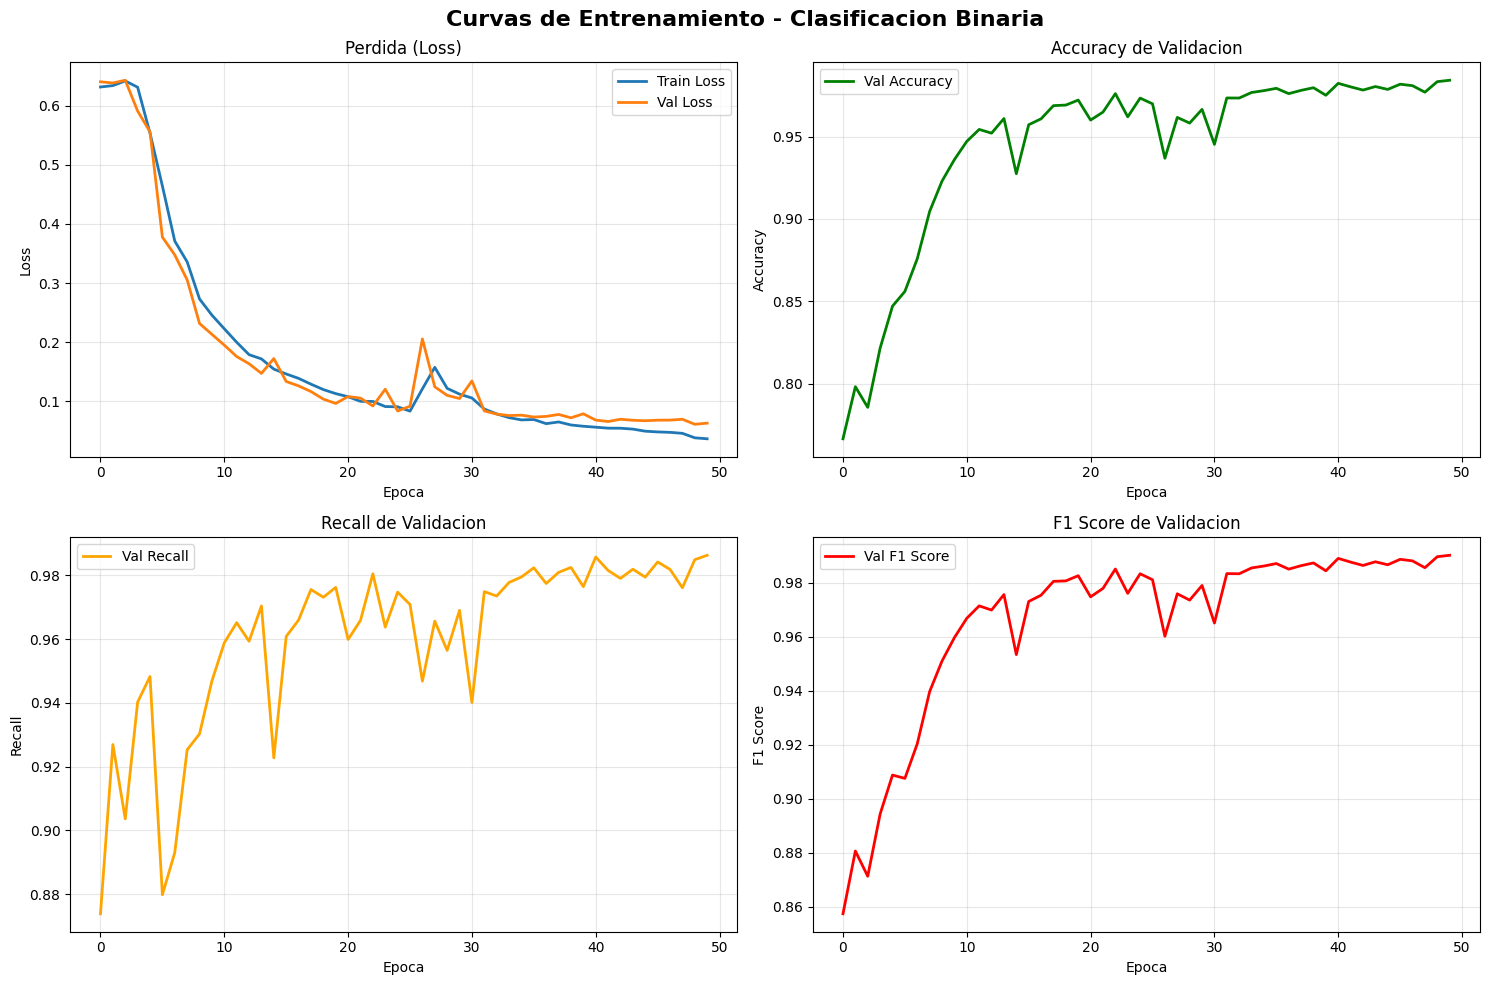


Graficas generadas y guardadas como 'training_curves.png'


In [21]:
# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Curvas de Entrenamiento - Clasificacion Binaria', fontsize=16, fontweight='bold')

# Loss
axes[0, 0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0, 0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoca')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Perdida (Loss)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(val_accuracies, label='Val Accuracy', color='green', linewidth=2)
axes[0, 1].set_xlabel('Epoca')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy de Validacion')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Recall
axes[1, 0].plot(val_recalls, label='Val Recall', color='orange', linewidth=2)
axes[1, 0].set_xlabel('Epoca')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Recall de Validacion')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# F1 Score
axes[1, 1].plot(val_f1s, label='Val F1 Score', color='red', linewidth=2)
axes[1, 1].set_xlabel('Epoca')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('F1 Score de Validacion')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGraficas generadas y guardadas como 'training_curves.png'")

## 16. Instrucciones para Deployment

Pasos para integrar el modelo entrenado en tu aplicacion backend.

In [22]:
print("\n" + "="*70)
print("INSTRUCCIONES PARA DEPLOYMENT")
print("="*70)

instructions = f"""
1. ARCHIVOS NECESARIOS:
   - {MODEL_PATH}
   - {SCALER_PATH}
   - {ENCODER_PATH}

2. COPIAR AL BACKEND:
   $ cp {MODEL_PATH} ../ecg_monitor/backend/
   $ cp {SCALER_PATH} ../ecg_monitor/backend/
   $ cp {ENCODER_PATH} ../ecg_monitor/backend/

3. ACTUALIZAR backend/main.py:
   - Cargar el modelo BiLSTM (2 clases)
   - Cargar scaler y label_encoder
   - Implementar funcion de prediccion binaria

4. ESPECIFICACIONES DEL MODELO:
   - Input: 180 muestras (0.5 segundos @ 360 Hz)
   - Output: 2 clases (Normal / Anormal)
   - Arquitectura: BiLSTM (128 -> 64 -> 2)

5. PROBAR BACKEND:
   $ cd ../ecg_monitor/backend
   $ python main.py

6. VERIFICAR FUNCIONAMIENTO:
   $ curl http://localhost:8000/health
   $ curl -X POST http://localhost:8000/predict \\
          -H "Content-Type: application/json" \\
          -d '{{"ecg_signal": [...180 valores...]}}'\n
"""

print(instructions)

print("="*70)
print(f"ENTRENAMIENTO COMPLETADO")
print(f"Mejor F1-Score: {best_val_f1:.4f}")
print(f"Clasificacion: Binaria (Normal/Anormal)")
print("="*70 + "\n")


INSTRUCCIONES PARA DEPLOYMENT

1. ARCHIVOS NECESARIOS:
   - best_ecg_bilstm_model.pth
   - scaler.pkl
   - label_encoder.pkl

2. COPIAR AL BACKEND:
   $ cp best_ecg_bilstm_model.pth ../ecg_monitor/backend/
   $ cp scaler.pkl ../ecg_monitor/backend/
   $ cp label_encoder.pkl ../ecg_monitor/backend/

3. ACTUALIZAR backend/main.py:
   - Cargar el modelo BiLSTM (2 clases)
   - Cargar scaler y label_encoder
   - Implementar funcion de prediccion binaria

4. ESPECIFICACIONES DEL MODELO:
   - Input: 180 muestras (0.5 segundos @ 360 Hz)
   - Output: 2 clases (Normal / Anormal)
   - Arquitectura: BiLSTM (128 -> 64 -> 2)

5. PROBAR BACKEND:
   $ cd ../ecg_monitor/backend
   $ python main.py

6. VERIFICAR FUNCIONAMIENTO:
   $ curl http://localhost:8000/health
   $ curl -X POST http://localhost:8000/predict \
          -H "Content-Type: application/json" \
          -d '{"ecg_signal": [...180 valores...]}'


ENTRENAMIENTO COMPLETADO
Mejor F1-Score: 0.9901
Clasificacion: Binaria (Normal/Anormal)

